## Retry and Delay

In [1]:
import os
import time
import logging
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("groq_api_key")

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# Initialize LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=api_key)

def call_llm_with_retry(prompt, retries=3, delay=2):
    for attempt in range(1, retries + 1):
        try:
            logging.info(f"Attempt {attempt} - Calling LLM")
            
            response = llm.invoke([HumanMessage(content=prompt)])
            
            logging.info("LLM call successful")
            return response.content
        
        except Exception as e:
            logging.error(f"Attempt {attempt} failed: {e}")
            
            if attempt < retries:
                time.sleep(delay)
            else:
                logging.critical("All retry attempts failed")
                raise

# Example usage
if __name__ == "__main__":
    prompt = "Explain what is an API in one sentence"
    
    result = call_llm_with_retry(prompt)
    print("Final Response:", result)

/Users/ishant162/miniconda3/envs/rag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-21 11:24:10,225 - INFO - Attempt 1 - Calling LLM
2026-04-21 11:24:10,532 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-21 11:24:10,550 - INFO - LLM call successful


Final Response: An API, or Application Programming Interface, is a set of defined rules and protocols that enables different software systems, applications, or services to communicate and exchange data with each other.


## Simple RAG

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
from pathlib import Path
import uuid
import chromadb
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings

# ── Config ────────────────────────────────────────────────────────────────────
PDF_DIR        = "./data/"
VECTOR_DIR     = "./data/vector_store"
EMBED_MODEL    = "all-MiniLM-L6-v2"
CHUNK_SIZE     = 1000
CHUNK_OVERLAP  = 200
TOP_K          = 3

# ── 1. Load PDFs ──────────────────────────────────────────────────────────────
docs = []
for pdf in Path(PDF_DIR).glob("**/*.pdf"):
    docs.extend(PyPDFLoader(str(pdf)).load())
print(f"Loaded {len(docs)} pages")

# ── 2.1 Fixed Chunk ──────────────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
chunks = splitter.split_documents(docs)
print(f"Split into {len(chunks)} chunks")

# ── 2.2 Semantic Chunk ──────────────────────────────────────────────────────────────────

# embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
# splitter = SemanticChunker(
#     embeddings=embeddings,
#     breakpoint_threshold_type="percentile",
#     breakpoint_threshold_amount=70
# )
# chunks = splitter.split_documents(docs)
# print(f"Split into {len(chunks)} semantic chunks")

# ── 3. Embed ──────────────────────────────────────────────────────────────────
model = SentenceTransformer(EMBED_MODEL)
texts = [c.page_content for c in chunks]
embeddings = model.encode(texts, show_progress_bar=True)

# ── 4. Store in ChromaDB ──────────────────────────────────────────────────────
os.makedirs(VECTOR_DIR, exist_ok=True)

# Check write access
if not os.access(VECTOR_DIR, os.W_OK):
    raise PermissionError(f"No write permission for {VECTOR_DIR}")

client     = chromadb.PersistentClient(path=VECTOR_DIR)
collection = client.get_or_create_collection("pdf_documents")

collection.add(
    ids        = [f"doc_{uuid.uuid4().hex[:8]}_{i}" for i in range(len(chunks))],
    embeddings = embeddings.tolist(),
    documents  = texts,
    metadatas  = [c.metadata for c in chunks]
)
print(f"Stored {collection.count()} chunks in vector store")


2026-04-21 11:24:12,965 - INFO - Use pytorch device_name: mps
2026-04-21 11:24:12,965 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Loaded 53 pages
Split into 229 chunks


Batches: 100%|██████████| 8/8 [00:02<00:00,  2.98it/s]
2026-04-21 11:24:19,492 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


Stored 629 chunks in vector store


In [3]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

# ── Shared setup (reuse model + collection from the main pipeline) ─────────────
texts        = [c.page_content for c in chunks]   # already have this from pipeline
tokenized    = [t.lower().split() for t in texts]
bm25         = BM25Okapi(tokenized)
reranker     = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# ── BM25 search ───────────────────────────────────────────────────────────────
def bm25_search(query, top_k):
    scores     = bm25.get_scores(query.lower().split())
    top_idx    = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [{"id": f"bm25_{i}", "content": texts[i], "score": scores[i]} for i in top_idx if scores[i] > 0]

# ── Vector search ─────────────────────────────────────────────────────────────
def vector_search(query, top_k):
    q_emb   = model.encode([query])[0].tolist()   # reuse SentenceTransformer from pipeline
    results = collection.query(query_embeddings=[q_emb], n_results=top_k)
    return [
        {"id": doc_id, "content": doc, "score": 1 - dist}
        for doc_id, doc, dist in zip(results["ids"][0], results["documents"][0], results["distances"][0])
    ]

# ── Reciprocal Rank Fusion ────────────────────────────────────────────────────
def rrf(bm25_results, vector_results, k=60):
    scores, doc_map = {}, {}
    for rank, doc in enumerate(bm25_results + vector_results, 1):
        scores[doc["id"]]  = scores.get(doc["id"], 0) + 1 / (k + rank)
        doc_map[doc["id"]] = doc
    return [doc_map[i] for i in sorted(scores, key=lambda x: scores[x], reverse=True)]

# ── RAG variants ──────────────────────────────────────────────────────────────
def rag(query, top_k=3):
    """Plain vector RAG"""
    results = vector_search(query, top_k)
    return _generate(query, results)

def rag_hybrid(query, top_k=3):
    """BM25 + Vector fused via RRF"""
    results = rrf(bm25_search(query, top_k * 3), vector_search(query, top_k * 3))[:top_k]
    return _generate(query, results)

def rag_hybrid_rerank(query, top_k=3):
    """BM25 + Vector → RRF → CrossEncoder rerank"""
    candidates = rrf(bm25_search(query, top_k * 4), vector_search(query, top_k * 4))[:top_k * 2]
    scores     = reranker.predict([(query, d["content"]) for d in candidates])
    results    = sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)[:top_k]
    return _generate(query, [d for d, _ in results])

def rag_hyde(query, top_k=3):
    """HyDE: generate hypothetical answer → use it for retrieval"""
    hypo    = llm.invoke([f"Write a concise answer to: {query}"]).content
    results = rrf(bm25_search(hypo, top_k * 3), vector_search(hypo, top_k * 3))[:top_k]
    return _generate(query, results)

# ── Shared answer generator ───────────────────────────────────────────────────
def _generate(query, results):
    context = "\n\n".join([d["content"] for d in results])
    if not context:
        return "No relevant context found."
    prompt = f"Use the context below to answer the question.\n\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"
    return llm.invoke([prompt]).content

# ── Run ───────────────────────────────────────────────────────────────────────
q = "What is attention is all you need?"

print("*"*50)
print("Basic RAG")
print(rag(q))
print("*"*50)
print("Hybrid RAG")
print(rag_hybrid(q))
print("*"*50)
print("Hybrid RAG rerank")
print(rag_hybrid_rerank(q))
print("*"*50)
print("Hyde RAG")
print(rag_hyde(q))
print("*"*50)

2026-04-21 11:24:22,273 - INFO - Use pytorch device: mps


**************************************************
Basic RAG


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]
2026-04-21 11:24:24,965 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The provided context does not directly answer the question "What is attention is all you need?" However, based on the given information, it appears to be related to the Transformer model, which is a type of neural network architecture introduced in the paper "Attention Is All You Need" by Vaswani et al.

In this context, "Attention Is All You Need" refers to the idea that attention mechanisms can be used as the primary component of a neural network architecture, replacing traditional recurrent neural network (RNN) and convolutional neural network (CNN) components. The attention mechanism allows the model to focus on specific parts of the input data when generating output, which is particularly useful for sequence-to-sequence tasks such as machine translation.

So, the answer to the question "What is attention is all you need?" is that it is a neural network architecture that relies solely on attention mechanisms to process input data, as introduced in the paper "Attention Is All You Ne

Batches: 100%|██████████| 1/1 [00:00<00:00, 67.34it/s]
2026-04-21 11:24:25,553 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


"Attention Is All You Need" is the title of a research paper by Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, and Illia Polosukhin. The paper proposes a new simple network architecture, the Transformer, which is based solely on attention mechanisms, dispensing with recurrence and convolutions. In other words, the authors argue that attention mechanisms are sufficient to handle complex sequence transduction tasks, and that traditional recurrent or convolutional neural networks are not necessary.
**************************************************
Hybrid RAG rerank


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.31it/s]
2026-04-21 11:24:26,707 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


"Attention Is All You Need" is the title of a research paper that proposes a new network architecture called the Transformer, which is based solely on attention mechanisms and does not use recurrence or convolutions. In other words, the paper argues that attention mechanisms are sufficient to handle sequence transduction tasks, and that other complex components like recurrent or convolutional neural networks are not necessary. The paper introduces a new simple network architecture that relies entirely on attention mechanisms to process input sequences, and demonstrates its effectiveness in various tasks.
**************************************************
Hyde RAG


2026-04-21 11:24:27,177 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
Batches: 100%|██████████| 1/1 [00:00<00:00,  4.70it/s]
2026-04-21 11:24:27,919 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


"Attention Is All You Need" is the title of the paper, and it refers to a new network architecture called the Transformer, which relies solely on attention mechanisms to draw global dependencies between input and output, dispensing with recurrence and convolutions. In other words, the paper proposes that attention mechanisms are sufficient to handle sequence transduction tasks, such as machine translation, without the need for recurrent or convolutional neural networks.
**************************************************


## RAG with Pinecone

In [4]:
########### Setting up Pinecone
from pinecone import Pinecone

pinecone_api_key = os.getenv("pinecone_api_key")

pc = Pinecone(api_key=pinecone_api_key)


########### Setting up Pinecone index
index = pc.Index("ragtest")

vectors = [
    (f"doc_{i}", embeddings[i].tolist(), {"text": texts[i]})
    for i in range(len(texts))
]


########### Injesting embeddings in the index
index.upsert(vectors=vectors)
print(f"Upserted {len(vectors)} vectors")

########### Function to do vector search in Pinecone
def vector_search_pinecone(query, top_k):
    print("*"*50)
    print("*"*50)
    print("*"*50)
    print("*"*50)
    print("vector search called")
    q_emb   = model.encode([query])[0].tolist()
    results = index.query(vector=q_emb, top_k=top_k, include_metadata=True)
    return [
        {"id": m["id"], "content": m["metadata"]["text"], "score": m["score"]}
        for m in results["matches"]
    ]

########### RAG with Pinecone
def rag_pinecone(query, top_k=3):
    """Plain vector RAG"""
    results = vector_search_pinecone(query, top_k)
    return _generate(query, results)

print(rag_pinecone(q))

Upserted 229 vectors
**************************************************
**************************************************
**************************************************
**************************************************
vector search called


Batches: 100%|██████████| 1/1 [00:00<00:00, 35.28it/s]
2026-04-21 11:24:36,496 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The provided context does not explicitly answer the question "What is attention is all you need?" However, it appears to be a reference to the paper "Attention Is All You Need" by Vaswani et al., which introduced the Transformer model.

In this context, "Attention Is All You Need" refers to the idea that attention mechanisms can be used as the primary component of a neural network architecture, replacing traditional recurrent neural network (RNN) and convolutional neural network (CNN) components. The paper proposed a model that relies entirely on self-attention mechanisms to process input sequences, eliminating the need for RNNs and CNNs.

In essence, the answer to the question is that "Attention Is All You Need" refers to a neural network architecture that uses attention mechanisms as the primary component, allowing it to efficiently process input sequences and achieve state-of-the-art results in various natural language processing tasks.


### RAG Pinecone with metadata filtering

In [5]:
# ── Store with metadata ───────────────────────────────────────────────────────
vectors = [
    (
        f"doc_{i}",
        embeddings[i].tolist(),
        {
            "text":        texts[i],
            "source_file": chunks[i].metadata.get("source_file", ""),
            "page":        chunks[i].metadata.get("page", 0),
        }
    )
    for i in range(len(texts))
]
index.upsert(vectors=vectors)

# ── Vector search with filter ─────────────────────────────────────────────────
def vector_search_with_metadata_filtering(query, top_k, filter=None):
    q_emb   = model.encode([query])[0].tolist()
    results = index.query(vector=q_emb, top_k=top_k, include_metadata=True, filter=filter)
    return [
        {"id": m["id"], "content": m["metadata"]["text"], "score": m["score"]}
        for m in results["matches"]
    ]

query = "What is attention is all you need paper?"


# ── Usage examples ────────────────────────────────────────────────────────────
# Single file
vector_search_with_metadata_filtering(query, top_k=3, filter={"source_file": {"$eq": "attention.pdf"}})

# Specific pages
vector_search_with_metadata_filtering(query, top_k=3, filter={"page": {"$in": [1, 2, 3]}})

# Page range
vector_search_with_metadata_filtering(query, top_k=3, filter={"page": {"$gte": 5, "$lte": 10}})

# Multiple conditions (AND)
vector_search_with_metadata_filtering(query, top_k=3, filter={
    "source_file": {"$eq": "attention.pdf"},
    "page":        {"$gte": 5}
})


def rag_hybrid_with_meta_data(query, top_k=3, filter=None):
    results = rrf(
        bm25_search(query, top_k * 3),
        vector_search_with_metadata_filtering(query, top_k * 3, filter=filter)
    )[:top_k]
    return _generate(query, results)

# Usage
rag_hybrid_with_meta_data("What is attention?", filter={"source_file": {"$eq": "attention.pdf"}, "page": {"$in": [1, 2, 3]}})

Batches: 100%|██████████| 1/1 [00:00<00:00,  3.86it/s]
2026-04-21 11:24:44,832 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


'Attention is not explicitly defined in the provided context, but based on the information given, it appears to be a mechanism used in neural networks, particularly in the context of natural language processing. Attention allows the model to focus on specific parts of the input data, such as words or phrases, when processing or generating text.\n\nIn the context of the encoder self-attention mechanism mentioned in the text, attention seems to refer to the ability of the model to weigh the importance of different input elements, such as words, relative to each other. This is illustrated by the examples given, where different attention heads appear to be learning different tasks, such as anaphora resolution.\n\nIn general, attention can be thought of as a way for the model to selectively concentrate on certain aspects of the input data, rather than processing all of it equally. This can help the model to better understand the context and relationships between different elements of the in

## Semantic Caching

In [6]:
import numpy as np

# ── Semantic Cache ────────────────────────────────────────────────────────────
cache = []   # list of {"embedding": ..., "query": ..., "answer": ...}
CACHE_THRESHOLD = 0.90   # cosine similarity threshold, tune as needed

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def check_cache(query_emb):
    for entry in cache:
        if cosine_similarity(query_emb, entry["embedding"]) >= CACHE_THRESHOLD:
            return entry["answer"]
    return None

def add_to_cache(query_emb, answer):
    cache.append({"embedding": query_emb, "answer": answer})

# ── RAG with semantic cache ───────────────────────────────────────────────────
def rag_with_semantic_caching(query, top_k=3):
    query_emb = model.encode([query])[0]

    # Check cache first
    cached = check_cache(query_emb)
    if cached:
        print("Cache hit!")
        return cached

    # Cache miss — run normal RAG
    results = vector_search(query, top_k)
    answer  = _generate(query, results)

    add_to_cache(query_emb, answer)
    return answer

In [7]:
answer = rag_with_semantic_caching("What is attention is all you need?")
print(answer)

Batches: 100%|██████████| 1/1 [00:00<00:00, 74.12it/s]
2026-04-21 11:24:45,855 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The provided context does not directly answer the question "What is attention is all you need?" However, based on the given information, it seems that "Attention is All You Need" is likely referring to a paper or concept that emphasizes the importance of the attention mechanism in deep learning models, particularly in the context of natural language processing.

In this context, the attention mechanism is described as a function that maps a query and a set of key-value pairs to an output, where the output is computed as a weighted sum. The attention mechanism is used to allow the model to focus on specific parts of the input data when making predictions.

The phrase "Attention is All You Need" is likely a reference to the paper "Attention Is All You Need" by Vaswani et al., which introduced the Transformer model and highlighted the importance of the attention mechanism in achieving state-of-the-art results in machine translation tasks. The paper argued that the attention mechanism is s

## ReAct Pattern (Langchain Agent)

In [8]:
from langchain_core.tools import tool
from langchain.agents import create_agent

from langchain_groq import ChatGroq

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("groq_api_key")

# 1. Define Tools
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

# 2. Create LLM
llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=api_key)

# 3. Build ReAct Agent
agent = create_agent(llm, tools=[add, multiply])

# 4. Run
result = agent.invoke({
    "messages": [{"role": "user", "content": "what is 2+3*5"}]
})

# 5. Print final answer
for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}")

2026-04-21 11:24:46,469 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-21 11:24:46,877 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


human: what is 2+3*5
ai: 
tool: 15
tool: 17
ai: The calculation is as follows: 
1. 3 * 5 = 15 
2. 2 + 15 = 17 

So, 2+3*5 = 17.


## ReAct Pattern (Using Langgraph)

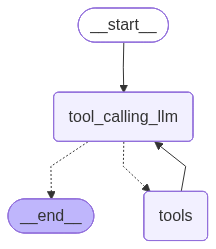

2026-04-21 11:24:47,986 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-21 11:24:48,291 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


================================ Human Message =================================

add 3 plus 3 , and then multiply by 6
================================== Ai Message ==================================
Tool Calls:
  add (yne4k2kk0)
 Call ID: yne4k2kk0
  Args:
    a: 3
    b: 3
  multiply (k732jedwm)
 Call ID: k732jedwm
  Args:
    a: 6
    b: 6
================================= Tool Message =================================
Name: add

6
================================= Tool Message =================================
Name: multiply

36
================================== Ai Message ==================================

First, 3 plus 3 equals 6. Then, 6 times 6 equals 36.


In [9]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage



## Custom functions for reACT agents

def multiply(a:int, b:int)-> int:
    """Multiplies two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.  
    """
    return a * b

# Tool
def add(a:int, b:int)-> int:
    """Adds two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.  
    """
    return a + b

def divide(a:int, b:int)-> float:
    """Divides two integers.
    
    Args:
        a (int): The first integer.
        b (int): The second integer.    
    """
    return a / b


tools = [add, multiply, divide]
llm_with_tools = llm.bind_tools(tools)


class State(TypedDict):
    """State for the graph."""
    messages: Annotated[list[AnyMessage], add_messages]


def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

messages = graph.invoke({"messages":HumanMessage(content="add 3 plus 3 , and then multiply by 6")})
for msg in messages["messages"]:
    msg.pretty_print()

## Plan and execute Pattern

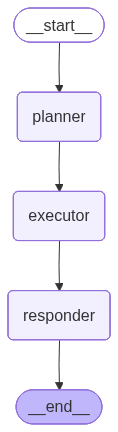

2026-04-21 11:24:52,355 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


**************************************************
{'query': '1. **Identify credible sources**: Look for reputable websites, research papers, and articles from well-known organizations and institutions in the field of artificial intelligence.', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'What Is a Credible Source? A Guide to Identifying Reliable Sources', 'url': 'https://jenni.ai/blog/what-is-a-credible-source', 'content': "# What Is a Credible Source? Knowing what makes a source credible is crucial for accurate research. Whether you're conducting research, working on an academic project, or making informed decisions, reliable information ensures accuracy and trustworthiness. A credible source is one that is **reliable, authoritative, and backed by accurate information**. These sources play a critical role in academic, professional, and personal research by ensuring that the information used is trustworthy and fact-based. Credible sources share spe

2026-04-21 11:25:03,264 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


PLAN:
  1. **Identify credible sources**: Look for reputable websites, research papers, and articles from well-known organizations and institutions in the field of artificial intelligence.
  2. **Browse recent publications and updates**: Visit online platforms, such as academic journals, tech blogs, and industry reports, to find the latest information on AI agent trends, advancements, and breakthroughs.
  3. **Explore online communities and forums**: Join online forums, social media groups, and discussion boards where AI professionals, researchers, and enthusiasts share their knowledge, experiences, and insights on the latest developments in AI agents.

RESULTS:
  Step: 1. **Identify credible sources**: Look for reputable websites, research papers, and articles from well-known organizations and institutions in the field of artificial intelligence. → [{'title': 'What Is a Credible Source? A Guide to Identifying Reliable Sources', 'url': 'https://jenni.ai/blog/what-is-a-credible-source',

In [10]:
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from typing import TypedDict, List
from langchain_tavily import TavilySearch

os.environ["TAVILY_API_KEY"] = os.getenv("tavily_api_key")


# 1. State
class PlanExecuteState(TypedDict):
    input: str
    plan: List[str]
    results: List[str]
    final_answer: str

# 2. Tool
tavily = TavilySearch()
tavily.invoke("Provide me current news on UAE")

# 3. Planner Node — breaks task into steps
def planner(state: PlanExecuteState) -> PlanExecuteState:
    prompt = f"Break this task into 2-3 simple steps (as a numbered list):\n{state['input']}"
    response = llm.invoke(prompt)
    
    # Parse steps from response
    lines = response.content.strip().split("\n")
    steps = [l.strip() for l in lines if l.strip() and l[0].isdigit()]
    
    return {"plan": steps}

# 4. Executor Node — executes one step at a time
def executor(state: PlanExecuteState) -> PlanExecuteState:
    results = []
    for step in state["plan"]:
        result = tavily.invoke({"query": step})  # run tool per step
        print("*"*50)
        print(result)
        print("*"*50)
        results.append(f"Step: {step} → {result['results']}")
    return {"results": results}

# 5. Responder Node — synthesizes final answer
def responder(state: PlanExecuteState) -> PlanExecuteState:
    context = "\n".join(state["results"])
    prompt = f"Given these results:\n{context}\n\nAnswer the original question: {state['input']}"
    response = llm.invoke(prompt)
    return {"final_answer": response.content}

# 6. Build Graph
graph = StateGraph(PlanExecuteState)

graph.add_node("planner",  planner)
graph.add_node("executor", executor)
graph.add_node("responder", responder)

graph.set_entry_point("planner")
graph.add_edge("planner",  "executor")
graph.add_edge("executor", "responder")
graph.add_edge("responder", END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

# # 7. Run
result = app.invoke({"input": "Research the latest trends in AI agents"})

print("PLAN:")
for step in result["plan"]:
    print(" ", step)

print("\nRESULTS:")
for r in result["results"]:
    print(" ", r)

print("\nFINAL ANSWER:")
print(result["final_answer"])